In [114]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [115]:
api = wandb.Api()

In [162]:
EXPERIMENT_GROUP = "./artifacts/2023-09-s13/experiments/distillation-layerwise/run7-sweep-lambda-layer"
# EXPERIMENT_GROUP = "./artifacts/2023-09-s13/experiments/distillation-layerwise/run4-sweep-lambda-layer"

In [163]:
def read_data(
    teacher,
    student,
    basis_name,
    lambda_task,
    arr_lambda_layers,
    dataset,
    training_size,
    verbose=False,
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_layer": {"$in": arr_lambda_layers}},
            {"config.policy": basis_name},
            {"config.training_size": training_size},
            {"config.dataset": dataset},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
        
        
        
        
        
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        

        rows.append(
            dict(
                seed=seed, 
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["lambda_layer"],
                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                teacher_acc=run.summary["teacher_acc"]
            )
        )

    
    df = pd.DataFrame(rows)
        
    df = df.groupby(by="lambda_layer").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-p1",
    student="resnet18customized",
    lambda_task=0.0,
    arr_lambda_layers=[1.0],
    basis_name="basis:prca-sortabs",
    training_size=1.0,
    verbose=True,
    dataset="cifar100-people",
)

summary

we have 5 runs
df.shape: (1, 8)


lambda_layer   val_acc                 val_agreement                  \
                    mean       std count          mean       std count   
0            1  0.221387  0.008254     5      0.226075  0.014681     5   

  teacher_acc  
         mean  
0        0.55

# Viz Distillation Over 20 Classes

## Comparison on `cifar100-resnet18-wb15`

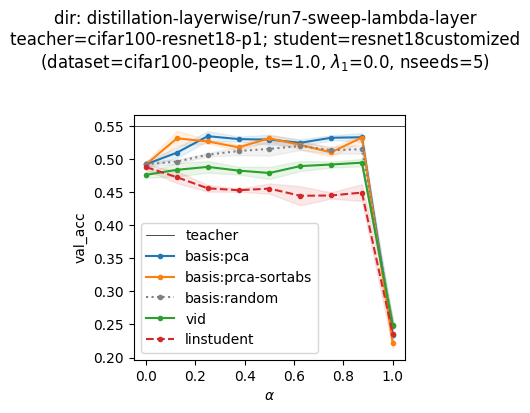

In [175]:
def ls(basis_name):
    if "random" in basis_name:
        return ":"
    elif basis_name == "linstudent":
        return "--"
    else:
        return "-"
    
def color(basis_name):
    if "random" in basis_name:
        return "gray"
    else:
        return None
    
def viz_distillation(teacher, student, arr_lambda_alphas, training_size):
        
    dataset = "cifar100-people"
    lambda_task = 0.0
    
    basis_names = [ 
        "basis:pca",
        "basis:prca-sortabs",
        "basis:random",
        "vid",
        "linstudent"
    ]
        
    ncols = 1
    nrows = 2
    
    plt.figure(figsize=(3.5*ncols, 3.5*2))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    
    for cix, col in enumerate(["val_acc", "val_agreement"][:1]):
        plt.subplot(nrows, ncols, cix * ncols + 1)
        plt.xlabel(r"$\alpha$")
        plt.ylabel(col)
        for bix, basis_name in enumerate(basis_names):
            df = read_data(
                teacher=teacher,
                student=student,
                lambda_task=lambda_task,
                arr_lambda_layers=arr_lambda_alphas,
                dataset=dataset,
                basis_name=basis_name,
                training_size=training_size,
                verbose=False
            )
            
            lambdas_layer = df["lambda_layer"]
            mean = df[col]["mean"]
            count = df[col]["count"].values[0]
            stderr = df[col]["std"] / (count ** 0.5)
                        
            if cix == bix == 0:
                plt.axhline(
                    df["teacher_acc"]["mean"].values[0], lw=0.5, color="k",
                    label="teacher"
                )
            
            
            plt.plot(
                lambdas_layer,
                mean,
                label=basis_name,
                ls=ls(basis_name),
                color=color(basis_name),
                marker="."
            )
            
            plt.fill_between(
                 lambdas_layer,
                 mean - stderr,
                 mean + stderr,
                 color=plt.gca().lines[-1].get_color(),
                alpha=0.1
            )
        plt.legend()

    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            f"teacher={teacher}; student={student}",
            f"(dataset={dataset}, ts={training_size}, $\lambda_1$={lambda_task}, nseeds={count})",
        ]),
        y=1.03
    )
viz_distillation(
    teacher = "cifar100-resnet18-p1",
    student="resnet18customized",
    training_size=1.0,
    arr_lambda_alphas=[
        0.0,
        0.125,
        0.25,
        0.375,
        0.5,
        0.625,
        0.75,
        0.875,
        1.0,
    ],
) 

# Comparison Across Teachers

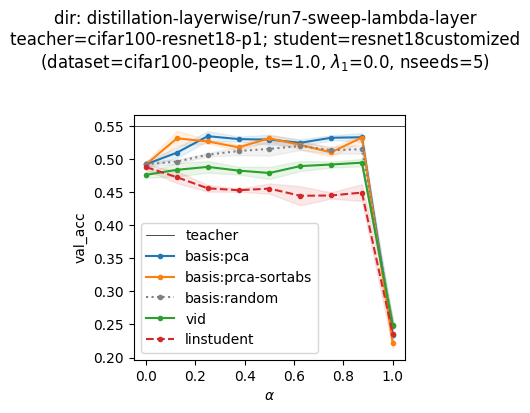

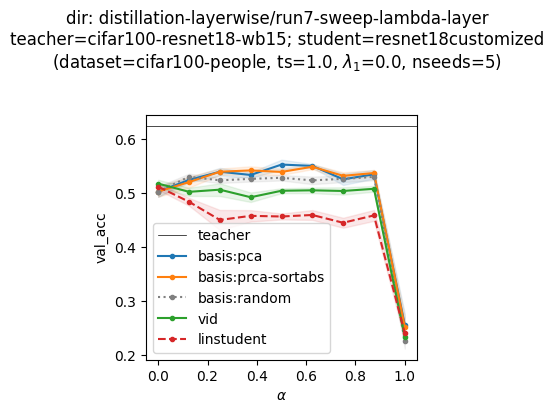

In [176]:
for teacher in ["cifar100-resnet18-p1", "cifar100-resnet18-wb15"]:
    
    viz_distillation(
        teacher=teacher,
        student="resnet18customized",
        training_size=1.0,
        arr_lambda_alphas=[
            0.0,
            0.125,
            0.25,
            0.375,
            0.5,
            0.625, 
            0.75,
            0.875,
            1.0,
        ],
    ) 

# Comparison Across Students

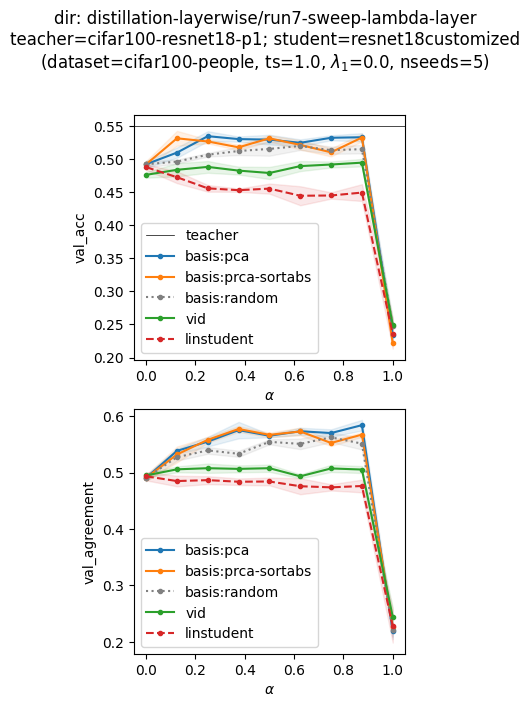

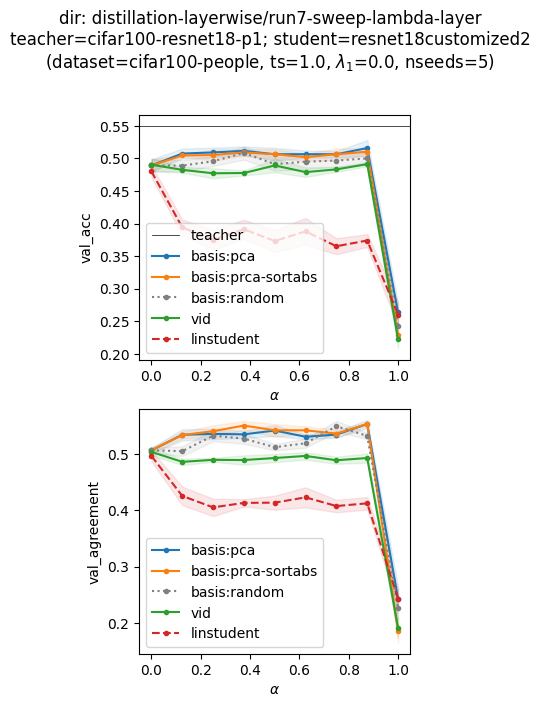

In [168]:
for student in ["resnet18customized", "resnet18customized2"]:

    viz_distillation(
        teacher="cifar100-resnet18-p1",
        student=student,
        training_size=1.0,
        arr_lambda_alphas=[
            0.0,
            0.125,
            0.25,
            0.375,
            0.5,
            0.625, 
            0.75,
            0.875,
            1.0,
        ],
    ) 

# Training Sizes

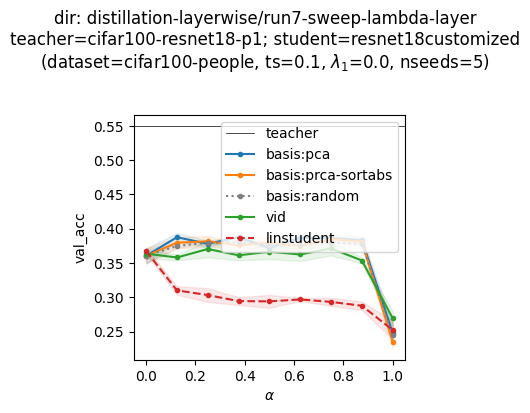

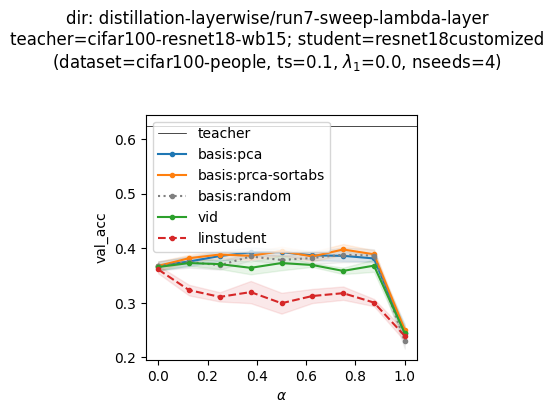

In [174]:
for teacher in ["cifar100-resnet18-p1", "cifar100-resnet18-wb15"]:
    viz_distillation(
        teacher=teacher,
        student="resnet18customized",
        training_size=0.1,
        arr_lambda_alphas=[
            0.0,
            0.125,
            0.25,
            0.375,
            0.5,
            0.625, 
            0.75,
            0.875,
            1.0,
        ],
    ) 

# Summary

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1- \alpha$ and $\lambda_3 = \alpha$

where  $\alpha \in \{10^{-6}, 10^{-5}, \dots, 10^{0}\}$.

*Aims:* 
- investigate whether the efficacy of layer loss
- investigate whether the efficacy of PRCA



*Conclusion:*
- Layer Loss with Orthogonal Basis Policies are generally better than learnable projectors on the majority of $\alpha$ values
    - for appropriate`pca` seems to be slighly better than `prca`
        - Interestingly, `random` is also very good.
- when reducing trainizing, the accuracy drop quite a lot, around 0.2.